## 1. Setup & Imports

Import libraries and configure the project root path to access `src/` modules.

In [134]:
import sys
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import re

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))



## 2. Load Raw Data

Load the raw `spam_assassin` CSV from the raw data directory and inspect its shape.

In [135]:
from src.config import DATA_DIR

db = pd.read_csv(DATA_DIR / "raw/email_origin.csv")

In [136]:
db.shape

(92189, 2)

In [137]:
db.head().iloc[0]["origin"]

'Received: from NAHOU-MSMBX01V ([192.168.110.39]) by NAHOU-MSMBX05V.corp.enron.com with Microsoft SMTPSVC(5.0.2195.1600);\n\t Fri, 29 Jun 2001 08:36:10 -0500\nX-MimeOLE: Produced By Microsoft Exchange V6.0.4418.65\ncontent-class: urn:content-classes:message\nSubject: FW: June 29 -- BNA, Inc. Daily Labor Report\nMIME-Version: 1.0\nContent-Type: text/plain;\nContent-Transfer-Encoding: binary\nDate: Fri, 29 Jun 2001 08:36:09 -0500\nMessage-ID: <77DA52C3FD86904D8209C9750CD310B9C79BB3@NAHOU-MSMBX01V.corp.enron.com>\nX-MS-Has-Attach: \nX-MS-TNEF-Correlator: <77DA52C3FD86904D8209C9750CD310B9C79BB3@NAHOU-MSMBX01V.corp.enron.com>\nThread-Topic: June 29 -- BNA, Inc. Daily Labor Report\nThread-Index: AcEAUaYbkE2KMWxCEdWxEABQi+MJ2QATr4SA\nFrom: "Hu, Sylvia" <Sylvia.Hu@ENRON.com>\nTo: "Acevedo, Felecia" <Felecia.Acevedo@ENRON.com>,\n\t"Brown, MeCole" <MeCole.Brown@ENRON.com>,\n\t"Cash, Michelle" <Michelle.Cash@ENRON.com>,\n\t"Castellano, Bonne" <Bonne.Castellano@ENRON.com>,\n\t"Johnson, Rick" <Rick

## 3. Feature Engineering

Extract numeric features from the raw text: URL count, exclamation/question marks, dollar signs, ALL-CAPS words, numbers, word count, and capitalisation ratio.

In [138]:
db["num_urls"]        = db["origin"].str.findall(r'https?://\S+|www\.\S+').str.len()
db["num_exclamation"] = db["origin"].str.count(r'!')
db["num_question"]    = db["origin"].str.count(r'\?')
db["num_dollar"]      = db["origin"].str.count(r'\$')
db["num_all_caps"]    = db["origin"].str.findall(r'\b[A-Z]{2,}\b').str.len()
db["num_numbers"]     = db["origin"].str.findall(r'\d+').str.len()
db["word_count"]      = db["origin"].str.split().str.len()
caps   = db["origin"].str.findall(r'[A-Z]').str.len()
letters = db["origin"].str.findall(r'[A-Za-z]').str.len()
db["capital_ratio"]   = np.where(letters > 0, caps / letters, 0)

In [139]:
import emoji

## 4. Emoji Count Feature

Count the number of emoji characters in each email text.

In [140]:
db["emoji_count"] = db["origin"].apply(emoji.emoji_count)

## 5. Exploratory Data Analysis

Visualise the class distribution with a pie chart and compare average feature values between spam and ham emails.

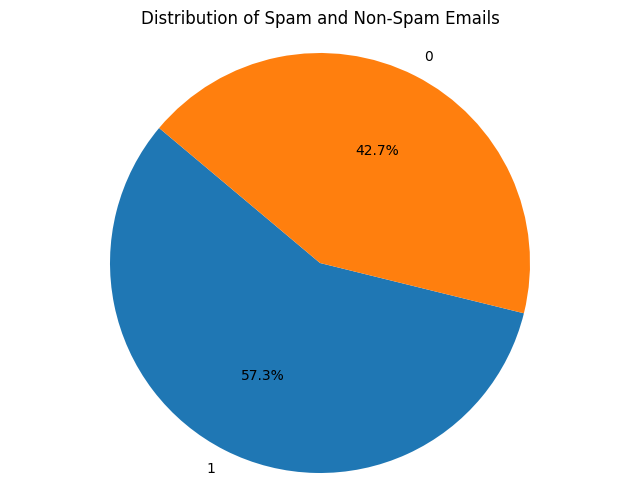

In [141]:
db['label'].value_counts()

import matplotlib.pyplot as plt
# Plotting
plt.figure(figsize=(8, 6))
plt.pie(db['label'].value_counts() , labels=db['label'].value_counts().index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Spam and Non-Spam Emails')
plt.axis('equal') 
plt.show()

In [142]:
db.info()

<class 'pandas.DataFrame'>
RangeIndex: 92189 entries, 0 to 92188
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   label            92189 non-null  int64  
 1   origin           92189 non-null  str    
 2   num_urls         92189 non-null  int64  
 3   num_exclamation  92189 non-null  int64  
 4   num_question     92189 non-null  int64  
 5   num_dollar       92189 non-null  int64  
 6   num_all_caps     92189 non-null  int64  
 7   num_numbers      92189 non-null  int64  
 8   word_count       92189 non-null  int64  
 9   capital_ratio    92189 non-null  float64
 10  emoji_count      92189 non-null  int64  
dtypes: float64(1), int64(9), str(1)
memory usage: 7.7 MB


In [143]:
# average emoji count of spam vs ham emails
db.groupby("label")["emoji_count"].mean()

label
0    0.077591
1    0.582686
Name: emoji_count, dtype: float64

In [144]:
# average exclamation of spam vs non-spam
db.groupby('label')['num_exclamation'].mean()


label
0    1.423259
1    8.978500
Name: num_exclamation, dtype: float64

In [146]:
# average num-dollar of spam vs non-spam
db.groupby('label')['num_dollar'].mean()

label
0     1.487373
1    10.759500
Name: num_dollar, dtype: float64

In [147]:
# averge question of spam vs non-spam
db.groupby('label')['num_question'].mean()

label
0    1.918805
1    5.073631
Name: num_question, dtype: float64

In [148]:
# avergae num_all_caps of spam vs non-spam
db.groupby('label')['num_all_caps'].mean()

label
0    58.450519
1    44.357643
Name: num_all_caps, dtype: float64

In [149]:
# average  capital_ratio of spam vs non-spam
db.groupby('label')['capital_ratio'].mean()

label
0    0.225176
1    0.190835
Name: capital_ratio, dtype: float64

In [150]:
# average num_numbers of spam vs non-spam
db.groupby('label')['num_numbers'].mean()

label
0    1034.982868
1     223.447320
Name: num_numbers, dtype: float64

In [151]:
# average number of urls in spam vs non-spam
db.groupby('label')['num_urls'].mean()

label
0    2.560065
1    4.705020
Name: num_urls, dtype: float64

In [152]:
# averge word count of spam vs non-spam 
db.groupby('label')['word_count'].mean()

label
0    575.019594
1    386.435594
Name: word_count, dtype: float64

## 6. Rename Column

Rename the `origin` column to `text` for consistency across all datasets.

In [153]:
#rename origin to text
db.rename(columns={"origin": "text"}, inplace=True)

In [154]:
# list row with highest emoji count in spam emails
db[db["label"] == 1].sort_values(by="emoji_count", ascending=False).head(1)

,label,text,num_urls,num_exclamation,num_question,num_dollar,num_all_caps,num_numbers,word_count,capital_ratio,emoji_count
86548,1,Received: from nahou-mscnx06p.corp.enron.com (...,1,0,8,0,37,563,2247,0.2288,1427


In [155]:
# list row with highest emoji count in ham emails
db[db["label"] == 0].sort_values(by="emoji_count", ascending=False).head(1)

,label,text,num_urls,num_exclamation,num_question,num_dollar,num_all_caps,num_numbers,word_count,capital_ratio,emoji_count
47813,0,Received: from NAHOU-MSMBX01V.corp.enron.com (...,7,2,37,419,347,2495,41913,0.050809,40


## 7. Deduplication

Remove duplicate rows based on the `text` column to avoid data leakage.

In [156]:
db.drop_duplicates(subset="text", inplace=True)

In [157]:
db.shape

(79861, 11)

In [158]:
db["label"].value_counts()

label
1    40464
0    39397
Name: count, dtype: int64

In [159]:
db["text"].iloc[0]

'Received: from NAHOU-MSMBX01V ([192.168.110.39]) by NAHOU-MSMBX05V.corp.enron.com with Microsoft SMTPSVC(5.0.2195.1600);\n\t Fri, 29 Jun 2001 08:36:10 -0500\nX-MimeOLE: Produced By Microsoft Exchange V6.0.4418.65\ncontent-class: urn:content-classes:message\nSubject: FW: June 29 -- BNA, Inc. Daily Labor Report\nMIME-Version: 1.0\nContent-Type: text/plain;\nContent-Transfer-Encoding: binary\nDate: Fri, 29 Jun 2001 08:36:09 -0500\nMessage-ID: <77DA52C3FD86904D8209C9750CD310B9C79BB3@NAHOU-MSMBX01V.corp.enron.com>\nX-MS-Has-Attach: \nX-MS-TNEF-Correlator: <77DA52C3FD86904D8209C9750CD310B9C79BB3@NAHOU-MSMBX01V.corp.enron.com>\nThread-Topic: June 29 -- BNA, Inc. Daily Labor Report\nThread-Index: AcEAUaYbkE2KMWxCEdWxEABQi+MJ2QATr4SA\nFrom: "Hu, Sylvia" <Sylvia.Hu@ENRON.com>\nTo: "Acevedo, Felecia" <Felecia.Acevedo@ENRON.com>,\n\t"Brown, MeCole" <MeCole.Brown@ENRON.com>,\n\t"Cash, Michelle" <Michelle.Cash@ENRON.com>,\n\t"Castellano, Bonne" <Bonne.Castellano@ENRON.com>,\n\t"Johnson, Rick" <Rick

## 8. Text Cleaning

Import the `clean_db_text` function for heavy-duty text cleaning (bracket/hex removal, normalisation).

In [ ]:
from src.preprocess import clean_db_text


Apply `clean_db_text` to every row and re-deduplicate after cleaning.

In [161]:
# data cleaning


db["text"] = db["text"].apply(clean_db_text)
db.drop_duplicates(subset="text", inplace=True)


In [162]:
db.head().iloc[0]["text"]

'received from nahou-msmbx01v ( [phonenumber] ) by nahou-msmbx05vcorpenroncom with microsoft smtpsvc( [phonenumber] ); fri [number] jun [phonenumber] [number] [number] - [phonenumber] x-mimeole produced by microsoft exchange v [phonenumber] content-class urncontent-classesmessage subject fw june [number] -- bna inc daily labor report mime-version [number] [number] content-type text/plain; content-transfer-encoding binary date fri [number] jun [phonenumber] [number] [number] - [phonenumber] message-id x-ms-has-attach x-ms-tnef-correlator thread-topic june [number] -- bna inc daily labor report thread-index aceauaybke2kmwxcedwxeabqi+mj2qatr4sa from "hu sylvia" to "acevedo felecia" "brown mecole" "cash michelle" "castellano bonne" "johnson rick" "lynch drew" "parker gilda" "sullivan kriste" "walker simone scott" "white bonnie" return-path [email] user id enrondlr pw bnaweb22 -----original message----- from "bna highlights" sent thursday june [number] [phonenumber] [number] pm to bna highl

In [117]:
db.head().iloc[0]["text"]

'received from nahou msmbx01v [phonenumber] by nahou msmbx05v corp enron com with microsoft smtpsvc [phonenumber] fri [number] jun [phonenumber] [number] [phonenumber] x mimeole produced by microsoft exchange v [phonenumber] content class urn content classes message subject fw june [number] bna inc daily labor report mime version [number] [number] content type text plain content transfer encoding binary date fri [number] jun [phonenumber] [number] [phonenumber] message id x ms has attach x ms tnef correlator thread topic june [number] bna inc daily labor report thread index aceauaybke2kmwxcedwxeabqi mj2qatr4sa from hu sylvia to acevedo felecia brown mecole cash michelle castellano bonne johnson rick lynch drew parker gilda sullivan kriste walker simone scott white bonnie return path sylvia hu enron com user id enrondlr pw bnaweb22 original message from bna highlights sent thursday june [number] [phonenumber] pm to bna highlights subject june [number] bna inc daily labor report ________

## 9. Regex Cleanup

Remove noise tokens: `[NUMBER]` placeholders, underscores, repeated `-+=` characters, and angle brackets/slashes.

In [163]:
# remove underscores from text
db["text"] = db["text"].str.replace("_", "", regex=False)

In [164]:
db.head().iloc[0]["text"]

'received from nahou-msmbx01v ( [phonenumber] ) by nahou-msmbx05vcorpenroncom with microsoft smtpsvc( [phonenumber] ); fri [number] jun [phonenumber] [number] [number] - [phonenumber] x-mimeole produced by microsoft exchange v [phonenumber] content-class urncontent-classesmessage subject fw june [number] -- bna inc daily labor report mime-version [number] [number] content-type text/plain; content-transfer-encoding binary date fri [number] jun [phonenumber] [number] [number] - [phonenumber] message-id x-ms-has-attach x-ms-tnef-correlator thread-topic june [number] -- bna inc daily labor report thread-index aceauaybke2kmwxcedwxeabqi+mj2qatr4sa from "hu sylvia" to "acevedo felecia" "brown mecole" "cash michelle" "castellano bonne" "johnson rick" "lynch drew" "parker gilda" "sullivan kriste" "walker simone scott" "white bonnie" return-path [email] user id enrondlr pw bnaweb22 -----original message----- from "bna highlights" sent thursday june [number] [phonenumber] [number] pm to bna highl

## 10. Advanced Text Processing 

Apply stopword removal and stemming via `process_text_advanced`. (Cell may be left unexecuted.)

In [ ]:
from src.preprocess import process_text_advanced
db["text"] = db["text"].apply(process_text_advanced)


In [170]:
db["text"].head(1).iloc[0]

'receiv nahou-msmbx01v [phonenumber] nahou-msmbx05vcorpenroncom microsoft smtpsvc( [phonenumber] ); fri [number] jun [phonenumber] [number] [number] [phonenumber] x-mimeol produc microsoft exchang v [phonenumber] content-class urncontent-classesmessag subject fw june [number] -- bna inc daili labor report mime-vers [number] [number] content-typ text/plain; content-transfer-encod binari date fri [number] jun [phonenumber] [number] [number] [phonenumber] message-id x-ms-has-attach x-ms-tnef-correl thread-top june [number] -- bna inc daili labor report thread-index aceauaybke2kmwxcedwxeabqi+mj2qatr4sa "hu sylvia" "acevedo felecia" "brown mecole" "cash michelle" "castellano bonne" "johnson rick" "lynch drew" "parker gilda" "sullivan kriste" "walker simon scott" "white bonnie" return-path [email] user id enrondlr pw bnaweb22 -----origin message----- "bna highlights" sent thursday june [number] [phonenumber] [number] pm bna highlight subject june [number] -- bna inc daili labor report daili 

In [175]:
db["text"].head(1).iloc[0]

'receiv nahou-msmbx01v [phonenumber] nahou-msmbx05vcorpenroncom microsoft smtpsvc [phonenumber] fri [number] jun [phonenumber] [number] [number] [phonenumber] x-mimeol produc microsoft exchang v [phonenumber] content-class urncontent-classesmessag subject fw june [number] -- bna inc daili labor report mime-vers [number] [number] content-typ text/plain content-transfer-encod binari date fri [number] jun [phonenumber] [number] [number] [phonenumber] message-id x-ms-has-attach x-ms-tnef-correl thread-top june [number] -- bna inc daili labor report thread-index aceauaybke2kmwxcedwxeabqi+mj2qatr4sa "hu sylvia" "acevedo felecia" "brown mecole" "cash michelle" "castellano bonne" "johnson rick" "lynch drew" "parker gilda" "sullivan kriste" "walker simon scott" "white bonnie" return-path [email] user id enrondlr pw bnaweb22 -----origin message----- "bna highlights" sent thursday june [number] [phonenumber] [number] pm bna highlight subject june [number] -- bna inc daili labor report daili labor

## 11. Save Cleaned Dataset

Write the cleaned and feature-engineered dataset to the processed data directory.

In [177]:
from src.config import PROCESSED_DATA_DIR
db.to_csv(PROCESSED_DATA_DIR / "cleaned_email_data_v1.csv", index=False)